In [1]:
import jax
import pickle
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
import numpy as np
import numpy as np_vanilla

In [3]:
jax.devices()[0]

GpuDevice(id=0, process_index=0)

In [ ]:
# with open("permutations.pkl", "rb") as f:
#     permutations = pickle.load(f)

In [50]:
np_vanilla.random.seed(20)
P = 300
input_dim = 28*28
(total_x_train, total_y_train), (total_x_test, total_y_test) = keras.datasets.mnist.load_data()
# subset to 0/1 data
train_selector = total_y_train <= 1
x_train = total_x_train[train_selector, :].reshape(-1, input_dim)
y_train = total_y_train[train_selector]

test_selector = total_y_test <= 1
x_test = total_x_test[test_selector, :, :].reshape(-1, input_dim)
y_test = total_y_test[test_selector]

# select a subset of images so P << N
seed = 42
# train_subset = subsets['train_subset']
# test_subset = subsets['test_subset']
train_subset = np_vanilla.random.choice(np.arange(x_train.shape[0]), size=[P], replace=False)
test_subset = np_vanilla.random.choice(np.arange(x_test.shape[0]), size=[P], replace=False)

x_train = x_train[train_subset, :]
y_train = y_train[train_subset]

x_test = x_test[test_subset, :]
y_test = y_test[test_subset]

# x_train = x_train[:, :]
# y_train = y_train[:]

# x_test = x_test[:, :]
# y_test = y_test[:]

# make outputs 1/-1 instead of 1/0
y_train = 2 * y_train.astype(np.int8) - 1
y_test = 2 * y_test.astype(np.int8) - 1

# standardize inputs

x_train = (x_train - np.mean(x_train, axis=1).reshape(-1, 1)) / np.std(x_train, axis=1).reshape(-1, 1)
x_test = (x_test -  np.mean(x_test, axis=1).reshape(-1, 1)) / np.std(x_test, axis=1).reshape(-1, 1)


In [51]:
def generate_permutation(size, steps):
    perm = np_vanilla.arange(size)
    for step in range(steps):
        i = np_vanilla.random.randint(size - 1)
        perm[i], perm[i + 1] = perm[i + 1], perm[i]
    return perm

In [52]:
permutation_steps = 10000
sigma = 0.5
lam = 100

In [53]:
# permutation = permutations[permutation_steps]['first_permutation']
# permutation = np.random.permutation(28*28)
permutation = generate_permutation(28*28, permutation_steps)
permuted_x_train = x_train[:, permutation]
permuted_x_test = x_test[:, permutation]

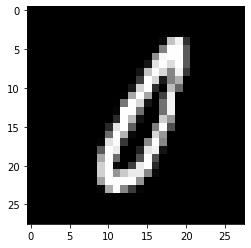

In [54]:
# results of permutation on single image
plt.imshow(x_train[0, :].reshape(28,28), cmap='gray')

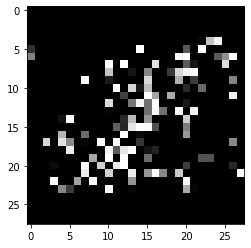

In [55]:
plt.imshow(x_train[0, permutation].reshape(28,28), cmap='gray')

In [56]:
def K_linear(a, b, sigma):
    # note input is P x N
    N = a.shape[1]
    return sigma**2 / N * np.dot(a, b.T)

def K_relu(a, b, sigma):
    # note input is P x N
    N = a.shape[1]
    
    # P x 1
    a_magnitudes = np.linalg.norm(a, axis=1, keepdims=True)
    b_magnitudes = np.linalg.norm(b, axis=1, keepdims=True)
    
    magnitude_products = np.dot(a_magnitudes, b_magnitudes.T)

    arccos_input = np.dot(a, b.T) / magnitude_products
    
    # bound input to [-1, 1] due to numerical stability issues
    arccos_input = np.maximum(arccos_input, -1)
    arccos_input = np.minimum(arccos_input, 1)
    
    theta = np.arccos(arccos_input)
    
    result = magnitude_products * (np.sin(theta) + (np.pi - theta) * np.cos(theta)) / np.pi
    return sigma**2 / N * result

def mean_predictor(X, X_1, X_2, y_1, y_2, sigma, K=K_relu):
    K_1 = K(X_1, X_1, sigma)
    K_1_inv = np.linalg.pinv(K_1)
    K_2 = K(X_2, X_2, sigma)
    K_2_inv = np.linalg.pinv(K_2)
    K_21 = K(X_2, X_1, sigma)
    
    factor = lam/(lam + sigma**(-2))
    # split computation of mean predictor into
    # K(x, X_2)(A) + K(x, X_1) B
    A = np.linalg.multi_dot([
        K_2_inv,
        y_2 - factor * np.linalg.multi_dot([
            K_21,
            K_1_inv,
            y_1
        ])
    ])

    B = factor * np.linalg.multi_dot([
        K_1_inv,
        y_1
    ])
    return np.dot(K(X, X_2, sigma), A) + np.dot(K(X, X_1, sigma), B) 


In [57]:
# task_1_kernel = K_relu(x_train, x_train, sigma)
# print(np.linalg.det(task_1_kernel))
# eigs = np_vanilla.linalg.eigvals(task_1_kernel)
# np.sort(eigs.real)

In [58]:
# Confirm mean predictor works when tasks 1 and 2 are same
predicted_output_1 = mean_predictor(
    X=x_train, 
    X_1=x_train, 
    X_2=x_train, 
    y_1=y_train, 
    y_2=y_train, 
    sigma=sigma)


In [59]:
predicted_output_1

DeviceArray([-0.8862933 , -1.0479295 ,  1.007641  ,  1.004554  ,
              0.95908976, -0.9545646 , -0.9474362 ,  0.9763918 ,
             -0.9792839 , -0.9647733 ,  0.96629167,  1.0170434 ,
              1.0983064 ,  0.9701145 ,  1.0017314 , -1.0098867 ,
             -1.0606683 ,  0.97431993,  0.9677458 , -0.96860516,
             -1.0352739 , -1.0887471 , -1.0281799 , -0.97870386,
              0.990085  ,  1.0205572 , -1.0339901 , -1.0021298 ,
             -0.99946016,  1.0145364 ,  0.9962292 , -0.93849444,
              1.0360234 , -1.1090596 , -0.951614  ,  1.0419397 ,
              0.89576757,  1.119342  ,  0.9880253 ,  1.020777  ,
              1.0276304 ,  0.9438345 , -0.8837768 ,  0.9556258 ,
             -0.94064564,  0.92107666, -1.0119435 , -0.9904072 ,
              0.97126186, -1.0306746 , -1.0212235 ,  0.9684617 ,
              1.0514685 ,  1.018096  ,  1.0305254 , -0.9658855 ,
              0.9744804 , -0.9697156 , -0.9513957 , -0.9476446 ,
             -0.95368606,

In [39]:
mse = lambda arr: np.mean(arr**2)
mse(predicted_output_1 - y_train)

DeviceArray(0.00797213, dtype=float32)

In [148]:
task_2_kernel = K_relu(permuted_x_train, permuted_x_train, sigma)
eigs = np_vanilla.linalg.eigvals(task_2_kernel)
# plt.scatter(eigs.real, eigs.imag)
np_vanilla.sort(eigs.real)

array([1.33922487e-03, 1.49594888e-03, 1.56697107e-03, 1.75642013e-03,
       1.83840992e-03, 1.92379521e-03, 1.99647597e-03, 2.03977618e-03,
       2.13803514e-03, 2.17707362e-03, 2.27297470e-03, 2.29559233e-03,
       2.41965591e-03, 2.42695445e-03, 2.57896422e-03, 2.63756956e-03,
       2.66189664e-03, 2.71546142e-03, 2.72972463e-03, 2.77423835e-03,
       2.84805568e-03, 2.85529951e-03, 2.96533667e-03, 3.05062160e-03,
       3.18887457e-03, 3.24818515e-03, 3.35734035e-03, 3.43605806e-03,
       3.51869711e-03, 3.69553058e-03, 3.76447127e-03, 3.87530238e-03,
       3.92631348e-03, 4.01715562e-03, 4.06809850e-03, 4.12999606e-03,
       4.24170820e-03, 4.27934108e-03, 4.47321543e-03, 4.52097459e-03,
       4.68105497e-03, 4.78929467e-03, 4.87223594e-03, 4.95401444e-03,
       5.03745209e-03, 5.18141361e-03, 5.27244713e-03, 5.29684825e-03,
       5.35246264e-03, 5.47968410e-03, 5.62917814e-03, 5.66963945e-03,
       5.82539337e-03, 6.00714609e-03, 6.01663394e-03, 6.09367341e-03,
      

In [149]:
predicted_output_2 = mean_predictor(
    X=x_train, 
    X_1=x_train, 
    X_2=permuted_x_train, 
    y_1=y_train, 
    y_2=y_train, 
    sigma=sigma)

In [150]:
# mean predictor not close to reasonable!
predicted_output_2[:20]

DeviceArray([ 1.2042391 , -2.6303678 ,  1.5188279 ,  2.2866316 ,
              2.322422  , -2.0260413 , -1.802156  ,  1.3850055 ,
             -0.70999   , -0.00913715,  1.2578795 ,  2.4075048 ,
              2.1046443 ,  1.7302556 ,  2.4601889 , -1.4337649 ,
             -1.3925297 ,  1.4083748 ,  1.9765801 , -1.1478825 ],            dtype=float32)

In [151]:
mse(predicted_output_2 - y_train)

DeviceArray(1.055151, dtype=float32)

In [139]:
!pwd

/home/gridsan/groups/DNAInteract/kalyan/continual_learning
